In [2]:
from bids import BIDSLayout
from bids.tests import get_test_data_path
import os

In [3]:
# Here we're using an example BIDS dataset that's bundled with the pybids tests
data_path = os.path.join(get_test_data_path(), 'ds000117')

# Initialize the layout
layout = BIDSLayout(data_path)

# Print some basic information about the layout
layout

/home/remi/.local/lib/python3.6/site-packages/bids/layout/models.py:152: FutureWarning: The 'extension' entity currently excludes the leading dot ('.'). As of version 0.14.0, it will include the leading dot. To suppress this warning and include the leading dot, use `bids.config.set_option('extension_initial_dot', True)`.
  FutureWarning)


BIDS Layout: ...kages/bids/tests/data/ds000117 | Subjects: 3 | Sessions: 12 | Runs: 18

Get first event file

In [4]:
event_file = layout.get(subject='01', 
                        session="mri", 
                        extension='.tsv', 
                        suffix='events', 
                        run="01")[0]
event_file

<BIDSDataFile filename='/home/remi/.local/lib/python3.6/site-packages/bids/tests/data/ds000117/sub-01/ses-mri/func/sub-01_ses-mri_task-facerecognition_run-01_events.tsv'>

Turn into a panda dataframe

In [89]:
data_frame = event_file.get_df()
data_frame.head()

,onset,duration,circle_duration,stim_type,trigger,button_pushed,response_time,stim_file
0,4.000,0.908,0.534,FAMOUS,5,4.0,2.158,func/f013.bmp
1,7.273,0.962,0.586,FAMOUS,6,4.0,1.233,func/f013.bmp
2,10.647,0.825,0.546,UNFAMILIAR,13,4.0,1.183,func/u014.bmp
3,13.838,0.968,0.597,UNFAMILIAR,14,4.0,0.930,func/u014.bmp
4,16.978,0.904,0.415,UNFAMILIAR,13,7.0,1.068,func/u016.bmp


## Identify unique trial types


In [22]:
# return it as a list so we can actually work with it
trial_type_set = list(set(data_frame.stim_type))
print(trial_type_set)

[nan, 'FAMOUS', 'UNFAMILIAR', 'SCRAMBLED']


In [12]:
import matplotlib as mpl
import matplotlib.pyplot as plt

## Only plot the first trial type 

### Plot onsets with duration as width

skip the `nan` trial_type for now


Text(0,0.5,'FAMOUS')

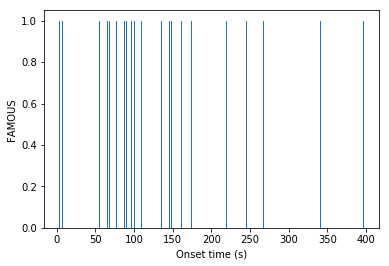

In [39]:
this_trial_type =  data_frame['stim_type']==trial_type_set[1]

fig, ax = plt.subplots()
ax.bar(those_onsets, 1, data_frame.duration[this_trial_type]) 
ax.set_xlabel('Onset time (s)')
ax.set_ylabel(trial_type_set[1])

### Plot ISI histogram

Text(0.5,0,'Inter-stimulus interval (s)')

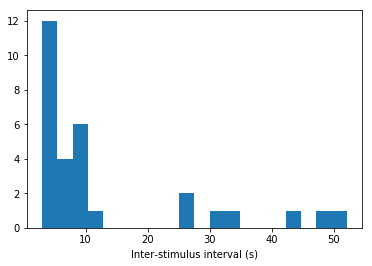

In [57]:
import numpy as np

those_onsets = data_frame.onset[this_trial_type].sort_values()
isi = np.diff(those_onsets)

fig, ax = plt.subplots()
ax.hist(isi, 20) 
ax.set_xlabel('Inter-stimulus interval (s)')

### Plot durations histogram

Text(0.5,0,'duration (s)')

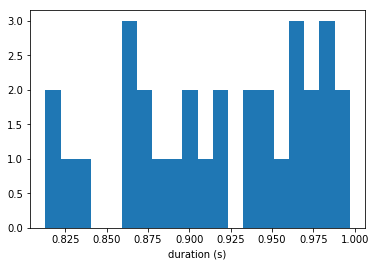

In [41]:
fig, ax = plt.subplots()
ax.hist(data_frame.duration[this_trial_type], 20) 
ax.set_xlabel('duration (s)')

### Plot response time

Text(0.5,0,'response time (s)')

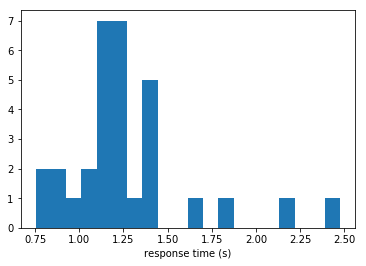

In [43]:
fig, ax = plt.subplots()
ax.hist(data_frame.response_time[this_trial_type], 20) 
ax.set_xlabel('response time (s)')

## Plot all trial types together

Have it all in one "mini" script.

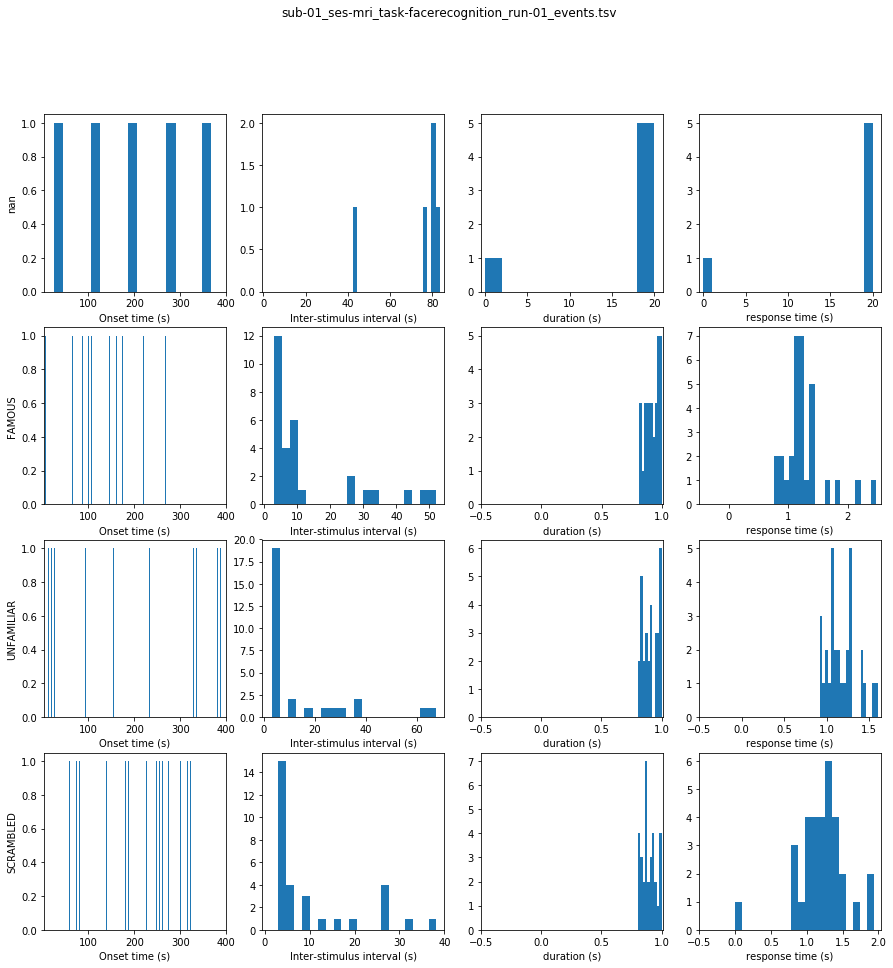

In [94]:
import numpy as np
import pandas as pd 
import matplotlib as mpl
import matplotlib.pyplot as plt

# TODO loop over all files?
event_file = layout.get(subject='01', 
                        session="mri", 
                        extension='.tsv', 
                        suffix='events', 
                        run="01")[0]

data_frame = event_file.get_df()

# TODO check if `trial_type` exist and filter by trial type according to this column
# if it does not exist assume all onsets come from the same trial type

# TODO check if `response_time` exists
# adapt number of columns and plotting accordingly

# FYI `stim_type` is NOT standard BIDS nomenclature
trial_type_set = list(set(data_frame.stim_type))

onset_min = min(data_frame.onset)
onset_max = max(data_frame.onset)

duration_max = max(data_frame.duration)

fig, ax = plt.subplots(len(trial_type_set), 4)

fig.set_size_inches(15, 15)

fig.suptitle(event_file.filename)


for i, trial_type in enumerate(trial_type_set):

    if pd.isna(trial_type):
        this_trial_type =  data_frame['stim_type'].isna()
    else: 
        this_trial_type =  data_frame['stim_type']==trial_type
    
    those_onsets = data_frame.onset[this_trial_type]

    isi = np.diff(those_onsets.sort_values())
    
    durations = data_frame.duration[this_trial_type]
    
    response_times = data_frame.response_time[this_trial_type]

    ax[i, 0].bar(those_onsets, 1, durations) 
    ax[i, 0].set_xlabel('Onset time (s)')
    ax[i, 0].set_ylabel(trial_type_set[i])
    ax[i, 0].set_xlim(onset_min, onset_max)

    ax[i, 1].hist(isi, 20)
    ax[i, 1].set_xlabel('Inter-stimulus interval (s)')
    ax[i, 1].set_xlim(-0.5)

    ax[i, 2].hist(durations) 
    ax[i, 2].set_xlabel('duration (s)')
    ax[i, 2].set_xlim(-0.5)
    
    # TODO plot negative response time in a different color
    # Question: do we want to flag very short response time as well? 
    ax[i, 3].hist(response_times, 20) 
    ax[i, 3].set_xlabel('response time (s)')
    ax[i, 3].set_xlim(-0.5)
    
    
fig.savefig('test.png')
    